# 📈 AI-Powered Stock Price Forecaster
### LSTM + Transformer 

## 📦 Cell 1: Install Dependencies

In [1]:
!pip install yfinance pandas numpy scikit-learn torch matplotlib ipywidgets

## 📚 Cell 2: Imports

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import Dataset, DataLoader

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## ⚙️ Cell 3: Configuration

In [3]:
# ── Configuration ──────────────────────────────────────────────
TICKERS       = ['AAPL', 'TSLA', 'GOOGL', 'MSFT', 'AMZN']  # stocks to analyze
START_DATE    = '2020-01-01'
END_DATE      = '2024-12-31'
SEQ_LEN       = 60      # look-back window (days)
FORECAST_DAYS = 14      # days to predict ahead
EPOCHS        = 50
BATCH_SIZE    = 32
LEARNING_RATE = 0.001
FEATURES      = ['Close', 'MA7', 'MA21', 'RSI', 'BB_upper', 'BB_lower', 'Return']

print('Configuration loaded!')
print(f'  Tickers      : {TICKERS}')
print(f'  Date range   : {START_DATE} → {END_DATE}')
print(f'  Sequence len : {SEQ_LEN} days')
print(f'  Forecast     : {FORECAST_DAYS} days')

Configuration loaded!
  Tickers      : ['AAPL', 'TSLA', 'GOOGL', 'MSFT', 'AMZN']
  Date range   : 2020-01-01 → 2024-12-31
  Sequence len : 60 days
  Forecast     : 14 days


## 📥 Cell 4: Download Stock Data

In [4]:
print('Downloading stock data...')
raw_data = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True)
close_prices = raw_data['Close']

print(f'\nData shape : {close_prices.shape}  (days × stocks)')
print(f'Date range : {close_prices.index[0].date()} → {close_prices.index[-1].date()}')
print(f'\nLatest closing prices:')
print(close_prices.tail(1).to_string())

[*********************100%***********************]  5 of 5 completed


Data shape : (1257, 5)  (days × stocks)
Date range : 2020-01-02 → 2024-12-30

Latest closing prices:
Ticker            AAPL        AMZN      GOOGL        MSFT        TSLA
Date                                                                 
2024-12-30  250.829803  221.300003  190.35994  420.758698  417.410004


## 🔧 Cell 5: Feature Engineering

In [5]:
def compute_rsi(series, period=14):
    """Relative Strength Index — measures momentum (0-100)."""
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

def add_features(df):
    """Add technical indicators to a single-stock OHLCV dataframe."""
    df = df.copy()

    # Trend indicators
    df['MA7']  = df['Close'].rolling(7).mean()     # 7-day moving average
    df['MA21'] = df['Close'].rolling(21).mean()    # 21-day moving average

    # Momentum
    df['RSI'] = compute_rsi(df['Close'])

    # Volatility — Bollinger Bands
    rolling_mean = df['Close'].rolling(20).mean()
    rolling_std  = df['Close'].rolling(20).std()
    df['BB_upper'] = rolling_mean + 2 * rolling_std
    df['BB_lower'] = rolling_mean - 2 * rolling_std

    # Daily return
    df['Return'] = df['Close'].pct_change()

    df.dropna(inplace=True)
    return df

# Test on AAPL
sample = raw_data.xs('AAPL', axis=1, level=1) if isinstance(raw_data.columns, pd.MultiIndex) else raw_data
sample = add_features(sample)
print('Features added successfully!')
print(sample[FEATURES].tail(3))

Features added successfully!
Price            Close         MA7        MA21        RSI    BB_upper  \
Date                                                                    
2024-12-26  257.612701  252.662637  245.558116  76.812074  259.228962   
2024-12-27  254.201370  252.962429  246.530423  69.300661  259.319030   
2024-12-30  250.829803  253.552067  247.348336  58.382083  258.955001   

Price         BB_lower    Return  
Date                              
2024-12-26  233.064790  0.003176  
2024-12-27  235.029494 -0.013242  
2024-12-30  236.872444 -0.013263  


## 📊 Cell 6: Visualize Stock Data

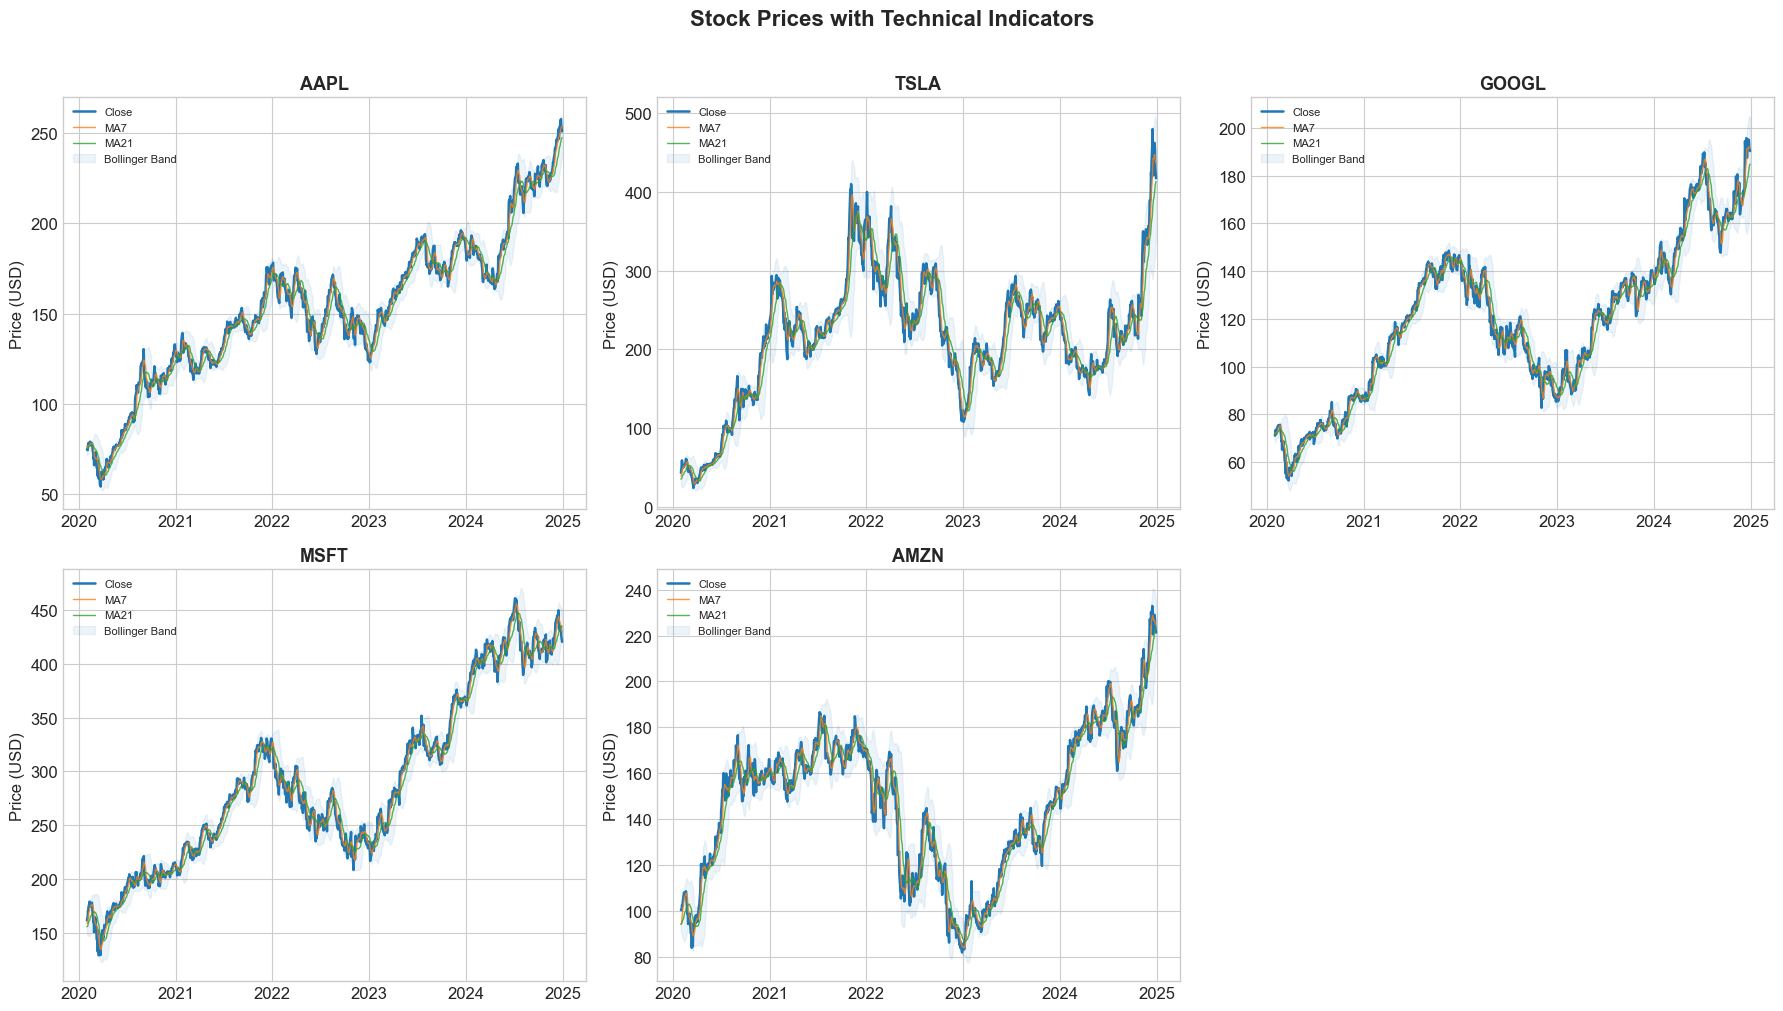

Chart saved as stock_overview.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    df = raw_data.xs(ticker, axis=1, level=1) if isinstance(raw_data.columns, pd.MultiIndex) else raw_data
    df = add_features(df)

    ax.plot(df.index, df['Close'],    label='Close',    linewidth=1.8, color='#1f77b4')
    ax.plot(df.index, df['MA7'],      label='MA7',      linewidth=1,   color='#ff7f0e', alpha=0.8)
    ax.plot(df.index, df['MA21'],     label='MA21',     linewidth=1,   color='#2ca02c', alpha=0.8)
    ax.fill_between(df.index, df['BB_lower'], df['BB_upper'], alpha=0.08, color='#1f77b4', label='Bollinger Band')

    ax.set_title(ticker, fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=8)

# Hide unused subplot
if len(TICKERS) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Stock Prices with Technical Indicators', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('stock_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as stock_overview.png')

## 🔢 Cell 7: Prepare Sequences

In [7]:
class StockDataset(Dataset):
    """PyTorch Dataset for sliding-window sequences."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


def prepare_data(ticker, seq_len=SEQ_LEN):
    """Download, engineer features, scale, and create sequences."""
    df = raw_data.xs(ticker, axis=1, level=1) if isinstance(raw_data.columns, pd.MultiIndex) else raw_data
    df = add_features(df)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[FEATURES])

    X, y = [], []
    for i in range(len(scaled) - seq_len):
        X.append(scaled[i : i + seq_len])      # 60 days of features
        y.append(scaled[i + seq_len][0])        # next day's Close (index 0)

    X, y = np.array(X), np.array(y)

    split     = int(len(X) * 0.8)
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]

    train_ds = StockDataset(X_tr, y_tr)
    test_ds  = StockDataset(X_te, y_te)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)

    return train_dl, X_te, y_te, scaler, df

# Test on AAPL
train_dl, X_te, y_te, scaler, df = prepare_data('AAPL')
print(f'Training batches : {len(train_dl)}')
print(f'Test samples     : {len(X_te)}')
print(f'Input shape      : {X_te.shape}  → (samples, seq_len, features)')

Training batches : 30
Test samples     : 236
Input shape      : (236, 60, 7)  → (samples, seq_len, features)


## 🧠 Cell 8: Define Models

In [8]:
# ── LSTM Model ─────────────────────────────────────────────────
class StockLSTM(nn.Module):
    """
    Stacked LSTM for time-series forecasting.
    input_size  = number of features per time step
    hidden_size = neurons in each LSTM layer
    num_layers  = stacked LSTM layers
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)     # (batch, seq, hidden)
        return self.fc(out[:, -1, :])   # last time step → prediction


# ── Transformer Model ──────────────────────────────────────────
class StockTransformer(nn.Module):
    """
    Transformer encoder for time-series forecasting.
    Uses self-attention to capture long-range dependencies.
    d_model must be divisible by nhead.
    """
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc    = nn.Dropout(dropout)  # simple positional dropout

        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.pos_enc(self.input_proj(x))   # (batch, seq, d_model)
        x = self.transformer(x)                # self-attention
        return self.fc(x[:, -1, :])            # last token → prediction


n_features = len(FEATURES)
lstm_model        = StockLSTM(input_size=n_features).to(device)
transformer_model = StockTransformer(input_size=n_features).to(device)

lstm_params        = sum(p.numel() for p in lstm_model.parameters())
transformer_params = sum(p.numel() for p in transformer_model.parameters())

print(f'LSTM parameters        : {lstm_params:,}')
print(f'Transformer parameters : {transformer_params:,}')

LSTM parameters        : 210,561
Transformer parameters : 102,593


## 🏋️ Cell 9: Training Loop

Training LSTM...
  [LSTM] Epoch  10/50 | Loss: 0.001065 | LR: 0.001000
  [LSTM] Epoch  20/50 | Loss: 0.000701 | LR: 0.001000
  [LSTM] Epoch  30/50 | Loss: 0.000622 | LR: 0.000500
  [LSTM] Epoch  40/50 | Loss: 0.000469 | LR: 0.000500
  [LSTM] Epoch  50/50 | Loss: 0.000418 | LR: 0.000500

Training Transformer...
  [Transformer] Epoch  10/50 | Loss: 0.005804 | LR: 0.001000
  [Transformer] Epoch  20/50 | Loss: 0.006119 | LR: 0.000500
  [Transformer] Epoch  30/50 | Loss: 0.002242 | LR: 0.000500
  [Transformer] Epoch  40/50 | Loss: 0.001674 | LR: 0.000500
  [Transformer] Epoch  50/50 | Loss: 0.000709 | LR: 0.000250


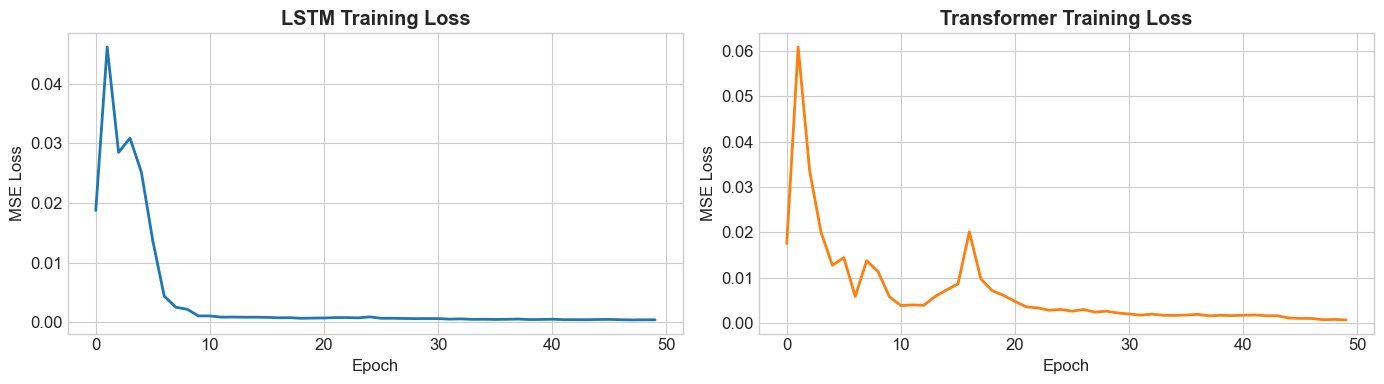

In [9]:
def train_model(model, train_dl, epochs=EPOCHS, lr=LEARNING_RATE, model_name='Model'):
    """
    Generic training loop.
    Returns list of epoch losses.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    losses = []
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_dl:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_dl)
        scheduler.step(avg_loss)
        losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'  [{model_name}] Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')

    return losses


print('Training LSTM...')
lstm_losses = train_model(lstm_model, train_dl, model_name='LSTM')

print('\nTraining Transformer...')
transformer_losses = train_model(transformer_model, train_dl, model_name='Transformer')

# Plot training curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(lstm_losses,        color='#1f77b4', linewidth=2)
ax1.set_title('LSTM Training Loss',        fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE Loss')

ax2.plot(transformer_losses, color='#ff7f0e', linewidth=2)
ax2.set_title('Transformer Training Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Cell 10: Evaluate & Compare Models


Metric               LSTM    Transformer
MAE        $        6.27 $       16.87
RMSE       $        7.84 $       21.72
MAPE       %        2.87 %        7.51


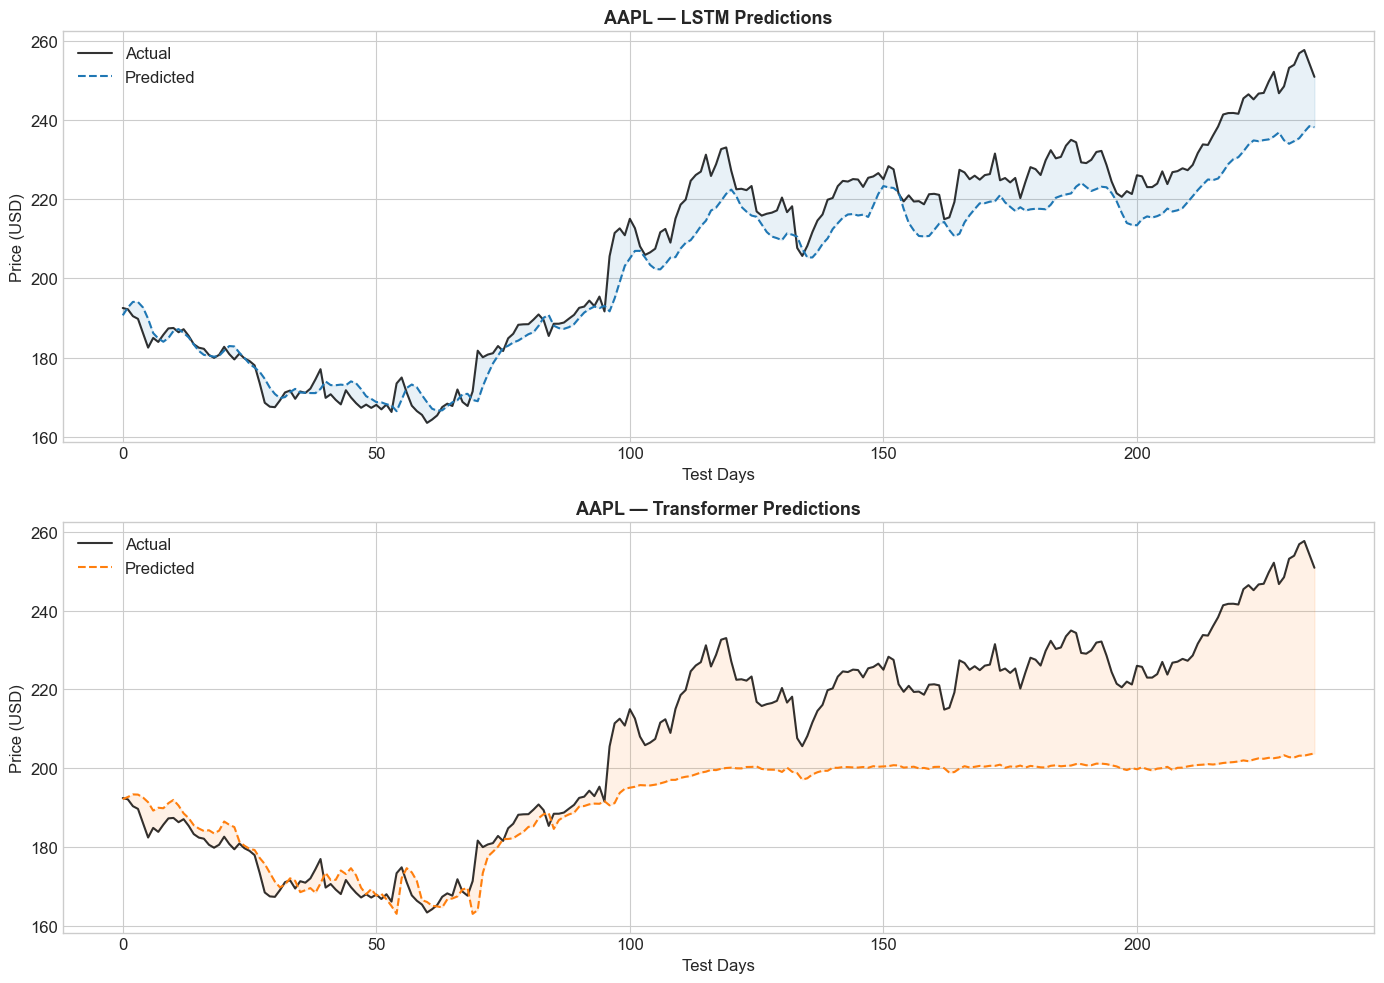

In [10]:
def evaluate_model(model, X_te, y_te, scaler):
    """Run inference and inverse-transform predictions."""
    model.eval()
    with torch.no_grad():
        X_t    = torch.tensor(X_te, dtype=torch.float32).to(device)
        preds  = model(X_t).cpu().numpy().flatten()

    def inverse_close(vals):
        """Invert MinMaxScaler for the Close price column only."""
        dummy = np.zeros((len(vals), len(FEATURES)))
        dummy[:, 0] = vals
        return scaler.inverse_transform(dummy)[:, 0]

    pred_prices   = inverse_close(preds)
    actual_prices = inverse_close(y_te)

    mae  = mean_absolute_error(actual_prices, pred_prices)
    rmse = np.sqrt(mean_squared_error(actual_prices, pred_prices))
    mape = np.mean(np.abs((actual_prices - pred_prices) / actual_prices)) * 100

    return pred_prices, actual_prices, {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


lstm_preds,   actual, lstm_metrics   = evaluate_model(lstm_model,        X_te, y_te, scaler)
transf_preds, _,      transf_metrics = evaluate_model(transformer_model, X_te, y_te, scaler)

# Print comparison table
print('\n' + '='*45)
print(f'{"Metric":<10} {"LSTM":>14} {"Transformer":>14}')
print('='*45)
for metric in ['MAE', 'RMSE', 'MAPE']:
    unit = '%' if metric == 'MAPE' else '$'
    print(f'{metric:<10} {unit}{lstm_metrics[metric]:>12.2f} {unit}{transf_metrics[metric]:>12.2f}')
print('='*45)

# Plot predictions
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, preds, title, color in zip(
    axes,
    [lstm_preds, transf_preds],
    ['LSTM Predictions', 'Transformer Predictions'],
    ['#1f77b4', '#ff7f0e']
):
    ax.plot(actual, label='Actual',     color='black',  linewidth=1.5, alpha=0.8)
    ax.plot(preds,  label='Predicted',  color=color,    linewidth=1.5, linestyle='--')
    ax.fill_between(range(len(actual)), actual, preds, alpha=0.1, color=color)
    ax.set_title(f'AAPL — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Test Days'); ax.set_ylabel('Price (USD)')
    ax.legend()

plt.tight_layout()
plt.savefig('predictions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔮 Cell 11: Multi-Day Forecast

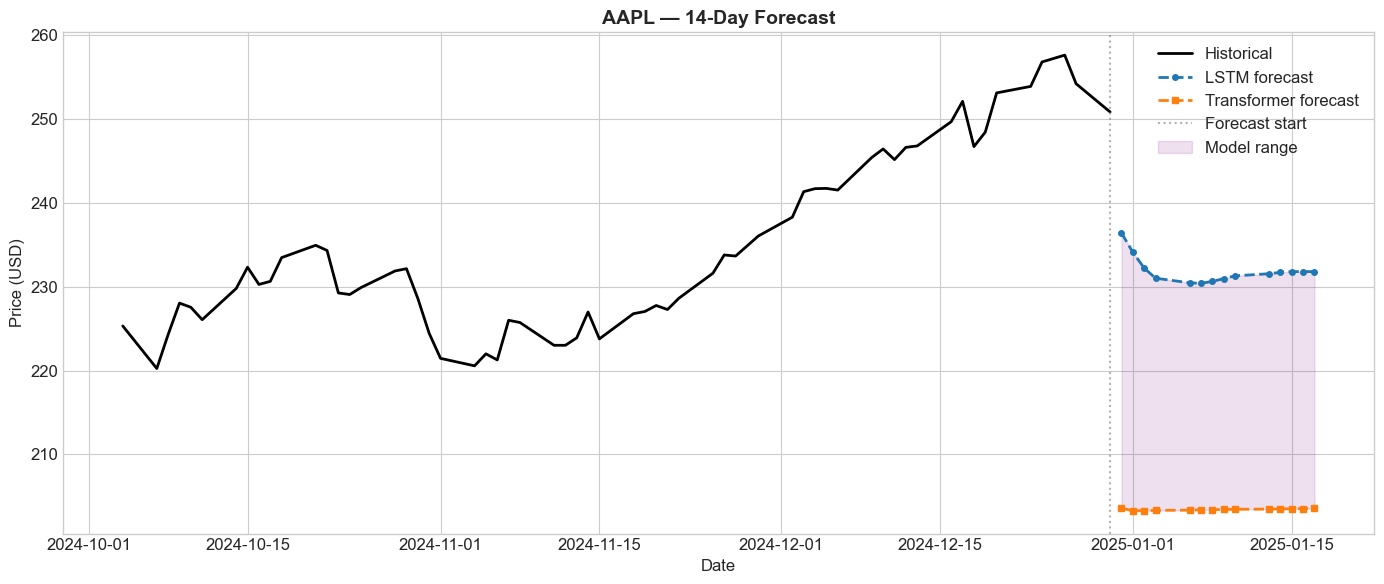


LSTM        — Day 1: $236.41  →  Day 14: $231.79
Transformer — Day 1: $203.60  →  Day 14: $203.56


In [11]:
def forecast_future(model, last_sequence, scaler, n_days=FORECAST_DAYS):
    """
    Auto-regressive forecast: predict n_days into the future.
    Each prediction is fed back as input for the next step.
    """
    model.eval()
    seq = last_sequence.copy()   # shape: (SEQ_LEN, n_features)
    forecasts = []

    with torch.no_grad():
        for _ in range(n_days):
            x   = torch.tensor(seq[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0).to(device)
            out = model(x).cpu().numpy().flatten()[0]
            forecasts.append(out)

            # Roll the window: append predicted close, carry over other features
            new_row       = seq[-1].copy()
            new_row[0]    = out       # update Close
            seq           = np.vstack([seq[1:], new_row])

    # Inverse transform
    dummy = np.zeros((len(forecasts), len(FEATURES)))
    dummy[:, 0] = forecasts
    return scaler.inverse_transform(dummy)[:, 0]


# Get last known sequence
scaled_data    = scaler.transform(df[FEATURES])
last_seq       = scaled_data[-SEQ_LEN:]

lstm_forecast        = forecast_future(lstm_model,        last_seq, scaler)
transformer_forecast = forecast_future(transformer_model, last_seq, scaler)

# Build date index for forecast
last_date       = df.index[-1]
forecast_dates  = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)
history_tail    = df['Close'].tail(60)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(history_tail.index,  history_tail.values,      label='Historical',           color='black',     linewidth=2)
plt.plot(forecast_dates,      lstm_forecast,             label=f'LSTM forecast',       color='#1f77b4',   linewidth=2, linestyle='--', marker='o', markersize=4)
plt.plot(forecast_dates,      transformer_forecast,      label=f'Transformer forecast',color='#ff7f0e',   linewidth=2, linestyle='--', marker='s', markersize=4)
plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.6, label='Forecast start')
plt.fill_between(forecast_dates,
                 np.minimum(lstm_forecast, transformer_forecast),
                 np.maximum(lstm_forecast, transformer_forecast),
                 alpha=0.12, color='purple', label='Model range')
plt.title(f'AAPL — {FORECAST_DAYS}-Day Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nLSTM        — Day 1: ${lstm_forecast[0]:.2f}  →  Day {FORECAST_DAYS}: ${lstm_forecast[-1]:.2f}')
print(f'Transformer — Day 1: ${transformer_forecast[0]:.2f}  →  Day {FORECAST_DAYS}: ${transformer_forecast[-1]:.2f}')

## 🤖 Cell 12: AI Analysis with Claude

In [12]:
def get_ai_analysis(ticker, current_price, lstm_metrics, transf_metrics,
                    lstm_forecast, transformer_forecast):

    lstm_pred = lstm_forecast[-1]
    transf_pred = transformer_forecast[-1]
    avg_pred = (lstm_pred + transf_pred) / 2

    # Trend
    trend = "BULLISH 📈" if avg_pred > current_price else "BEARISH 📉"

    # Best model
    better_model = "LSTM" if lstm_metrics['rmse'] < transf_metrics['rmse'] else "Transformer"

    # Risk
    volatility = abs(lstm_pred - transf_pred)
    if volatility > 5:
        risk = "HIGH"
    elif volatility > 2:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    return f"""
    ==============================
    📊 STOCK ANALYSIS — {ticker}
    ==============================

    Current Price: ${current_price:.2f}

    🔮 Predictions:
    - LSTM: ${lstm_pred:.2f}
    - Transformer: ${transf_pred:.2f}
    - Avg Forecast: ${avg_pred:.2f}

    📈 Trend: {trend}

    🤖 Best Model: {better_model}

    ⚠️ Risk Level: {risk}

    💡 Insight:
    The model predicts a {trend.lower()} trend based on historical patterns.
    """

## 🔁 Cell 13: Train All Tickers

In [13]:
all_results = {}

for ticker in TICKERS:
    print(f'\n──── {ticker} ────')

    train_dl_t, X_te_t, y_te_t, scaler_t, df_t = prepare_data(ticker)

    model_t = StockLSTM(input_size=len(FEATURES)).to(device)
    _       = train_model(model_t, train_dl_t, epochs=EPOCHS, model_name=ticker)

    preds_t, actual_t, metrics_t = evaluate_model(model_t, X_te_t, y_te_t, scaler_t)

    all_results[ticker] = {
        'model':   model_t,
        'scaler':  scaler_t,
        'metrics': metrics_t,
        'preds':   preds_t,
        'actual':  actual_t,
        'df':      df_t
    }

    print(f'  MAE: ${metrics_t["MAE"]:.2f}  RMSE: ${metrics_t["RMSE"]:.2f}  MAPE: {metrics_t["MAPE"]:.2f}%  ✅')

# Summary table
print('\n' + '='*55)
print(f'{"Ticker":<8} {"MAE ($)":>10} {"RMSE ($)":>10} {"MAPE (%)":>10}')
print('='*55)
for t, r in all_results.items():
    m = r['metrics']
    print(f'{t:<8} {m["MAE"]:>10.2f} {m["RMSE"]:>10.2f} {m["MAPE"]:>10.2f}')
print('='*55)


──── AAPL ────
  [AAPL] Epoch  10/50 | Loss: 0.001155 | LR: 0.001000
  [AAPL] Epoch  20/50 | Loss: 0.001139 | LR: 0.001000
  [AAPL] Epoch  30/50 | Loss: 0.001993 | LR: 0.000500
  [AAPL] Epoch  40/50 | Loss: 0.000520 | LR: 0.000125
  [AAPL] Epoch  50/50 | Loss: 0.000502 | LR: 0.000125
  MAE: $6.41  RMSE: $8.01  MAPE: 2.94%  ✅

──── TSLA ────
  [TSLA] Epoch  10/50 | Loss: 0.006532 | LR: 0.001000
  [TSLA] Epoch  20/50 | Loss: 0.001303 | LR: 0.001000
  [TSLA] Epoch  30/50 | Loss: 0.001123 | LR: 0.001000
  [TSLA] Epoch  40/50 | Loss: 0.000829 | LR: 0.000500
  [TSLA] Epoch  50/50 | Loss: 0.000666 | LR: 0.000500
  MAE: $9.48  RMSE: $13.84  MAPE: 3.85%  ✅

──── GOOGL ────
  [GOOGL] Epoch  10/50 | Loss: 0.002686 | LR: 0.001000
  [GOOGL] Epoch  20/50 | Loss: 0.002420 | LR: 0.001000
  [GOOGL] Epoch  30/50 | Loss: 0.001062 | LR: 0.000500
  [GOOGL] Epoch  40/50 | Loss: 0.000771 | LR: 0.000250
  [GOOGL] Epoch  50/50 | Loss: 0.000642 | LR: 0.000125
  MAE: $7.91  RMSE: $9.35  MAPE: 4.66%  ✅

──── MSF

## 💾 Cell 14: Save Models

In [14]:
import os, pickle
os.makedirs('saved_models', exist_ok=True)

# Save LSTM and Transformer
torch.save(lstm_model.state_dict(),        'saved_models/aapl_lstm.pt')
torch.save(transformer_model.state_dict(), 'saved_models/aapl_transformer.pt')

# Save all ticker models
for ticker, result in all_results.items():
    torch.save(result['model'].state_dict(), f'saved_models/{ticker.lower()}_lstm.pt')
    with open(f'saved_models/{ticker.lower()}_scaler.pkl', 'wb') as f:
        pickle.dump(result['scaler'], f)

print('Models saved to saved_models/')

# Load example
loaded_model = StockLSTM(input_size=len(FEATURES)).to(device)
loaded_model.load_state_dict(torch.load('saved_models/aapl_lstm.pt', map_location=device))
loaded_model.eval()
print('Model loaded and ready for inference!')

Models saved to saved_models/
Model loaded and ready for inference!
